In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import QuantileTransformer
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score, silhouette_samples


# Set a seaborn style for attractive visuals
sns.set_style("whitegrid")
sns.set_theme()


In [0]:
# loading Dataset

TABLE_NAME = 'workspace.e_commerce.e_commerce_clean_dataset'

print(f'{'=' * 10} Dataset is loading........')
df = spark.table(TABLE_NAME).toPandas()
print(f'{'=' * 10} Dataset is loaded successful')

========== Dataset is loading........
========== Dataset is loaded successful


In [0]:
# Shape of the dataset
print(f'Shape of the dataset: {df.shape}') #// (Rows, column)

Shape of the dataset: (989571, 13)


In [0]:
reference_date = df['Invoice_Date'].max()

df_cluster = df.groupby('Customer_ID').agg({
    'Total_price': 'sum',
    'Invoice': 'nunique',
    'Invoice_Date': lambda x: (reference_date - x.max()).days
}).reset_index()


In [0]:
df_cluster.columns = [
    'Customer_ID',
    'Monetary',
    'Frequency',
    'Recency'
]

df_cluster['Monetary_log']  = np.log1p(df_cluster['Monetary'])
df_cluster['Frequency_log'] = np.log1p(df_cluster['Frequency'])

In [0]:
df_cluster

,Customer_ID,Monetary,Frequency,Recency,Monetary_log,Frequency_log
0,0.0,3001843.50,3077,1,14.914737,8.032035
1,12346.0,77556.46,12,320,11.258774,2.564949
2,12347.0,4696.71,7,34,8.454830,2.079442
3,12348.0,2019.40,5,70,7.611051,1.791759
4,12349.0,4428.69,4,13,8.396085,1.609438
...,...,...,...,...,...,...
5856,18283.0,2456.90,21,4,7.807063,3.091042
5857,18284.0,461.68,1,426,6.137036,0.693147
5858,18285.0,427.00,1,655,6.059123,0.693147
5859,18286.0,1296.43,2,471,7.168141,1.098612


In [0]:
CLUSTER_FEATURES = df_cluster[['Recency', 'Monetary_log', 'Frequency_log']].copy()
FEATURE_NAMES = CLUSTER_FEATURES.columns
FEATURE_NAMES

Index(['Recency', 'Monetary_log', 'Frequency_log'], dtype='object')

In [0]:
X5 = CLUSTER_FEATURES

qt = QuantileTransformer(
    n_quantiles = 5,
    output_distribution = 'uniform',
    random_state = 42
)
scaled = qt.fit_transform(X5)
X5_scaled = pd.DataFrame(scaled, columns=FEATURE_NAMES, index=CLUSTER_FEATURES.index)
X5_scaled

,Recency,Monetary_log,Frequency_log
0,0.010000,1.000000,1.000000
1,0.700000,0.873108,0.770391
2,0.280000,0.775788,0.750000
3,0.400000,0.723758,0.646241
4,0.130000,0.773750,0.580482
...,...,...,...
5856,0.040000,0.753306,0.792486
5857,0.785615,0.333279,0.000000
5858,0.945531,0.312150,0.000000
5859,0.817039,0.608417,0.396241


In [0]:
k = 4

km5 = KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 30,
    max_iter = 300
)

labels5 = km5.fit_predict(X5_scaled)
inertial = km5.inertia_

sil_avg_1= silhouette_score(X5_scaled, labels5)

print(f'Inertia: {round(inertial,2)}')
print(f'Silhoutte: {round(sil_avg_1,2)}')


Inertia: 295.98
Silhoutte: 0.45


In [0]:
base_iter5 = X5_scaled.copy()
base_iter5['cluster']= labels5
sizes4 = base_iter5['cluster'].value_counts().sort_index()
sizes4

cluster
0    2109
1    1614
2     871
3    1267
Name: count, dtype: int64

In [0]:
sizes4 = base_iter5["cluster"].value_counts().sort_index()
FEATURE_NAMES = CLUSTER_FEATURES.columns
means3 = base_iter5.groupby("cluster")[FEATURE_NAMES].mean().round(3)
means3

,Recency,Monetary_log,Frequency_log
cluster,,,
0,0.228,0.719,0.717
1,0.686,0.486,0.520
2,0.254,0.331,0.251
3,0.785,0.255,0.001


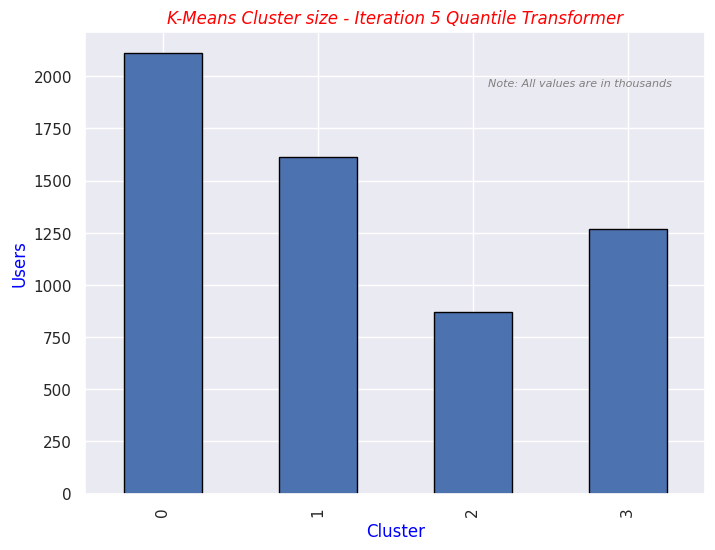

In [0]:

# specifing the figure size 
plt.figure(figsize = (8,6))

base_iter5['cluster'].value_counts().sort_index().plot(kind='bar',
                                                       edgecolor = 'black',
                                                       linewidth=1)

plt.title('K-Means Cluster size - Iteration 5 Quantile Transformer',
          color = 'red',
          style = 'italic')

ax = plt.gca()
plt.text(0.65, 0.90, 'Note: All values are in thousands',  
        verticalalignment='top',
        fontsize=8,
        transform = ax.transAxes,
        color = 'grey',
        style = 'italic')

plt.xlabel('Cluster', color = 'blue')
plt.ylabel('Users', color = 'blue')
plt.grid(True)
plt.show()

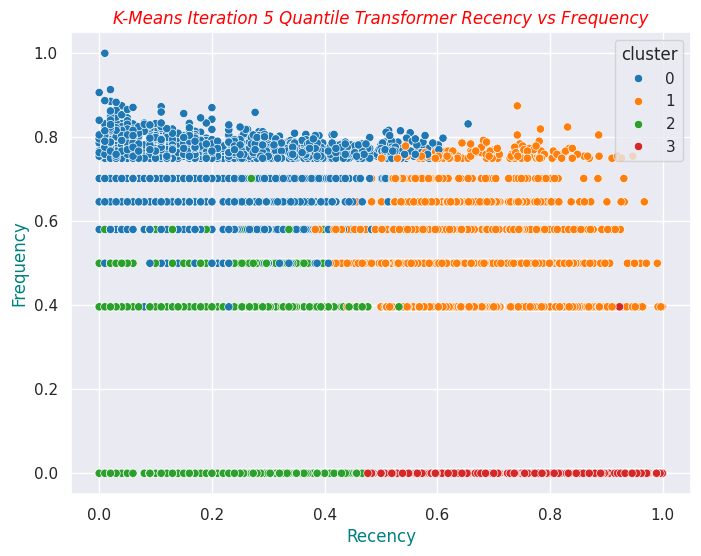

In [0]:
# scatter plot (No PCA)

# Recency vs Frequency
import seaborn as sns

plt.figure(figsize= (8,6))
sns.scatterplot(
    data = base_iter5,
    x = 'Recency',
    y = 'Frequency_log',
    hue = 'cluster',
    palette = 'tab10',
)

plt.title('K-Means Iteration 5 Quantile Transformer Recency vs Frequency',
          color = 'red',
          style = 'italic')
plt.xlabel('Recency', color = 'teal')
plt.ylabel('Frequency', color = 'teal')
plt.show()

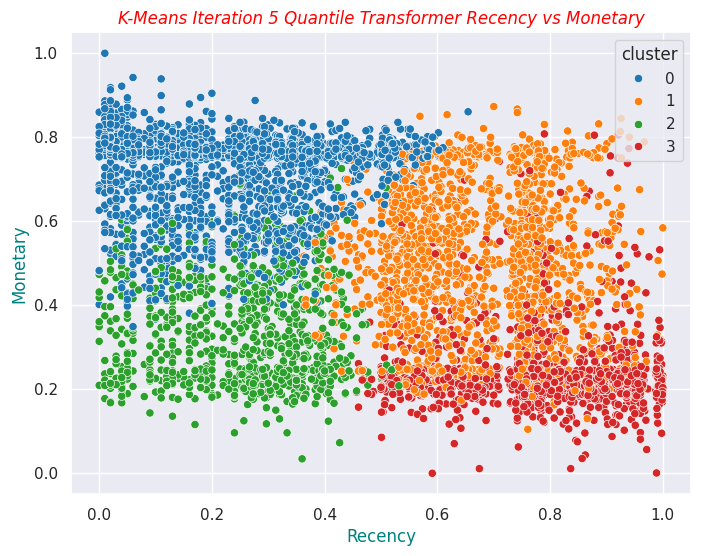

In [0]:
# scatter plot (No PCA)

# Recency vs Monetary
import seaborn as sns

plt.figure(figsize= (8,6))
sns.scatterplot(
    data = base_iter5,
    x = 'Recency',
    y = 'Monetary_log',
    hue = 'cluster',
    palette = 'tab10',
)

plt.title('K-Means Iteration 5 Quantile Transformer Recency vs Monetary',
          color = 'red',
          style = 'italic')
plt.xlabel('Recency', color = 'teal')
plt.ylabel('Monetary', color = 'teal')
plt.show()

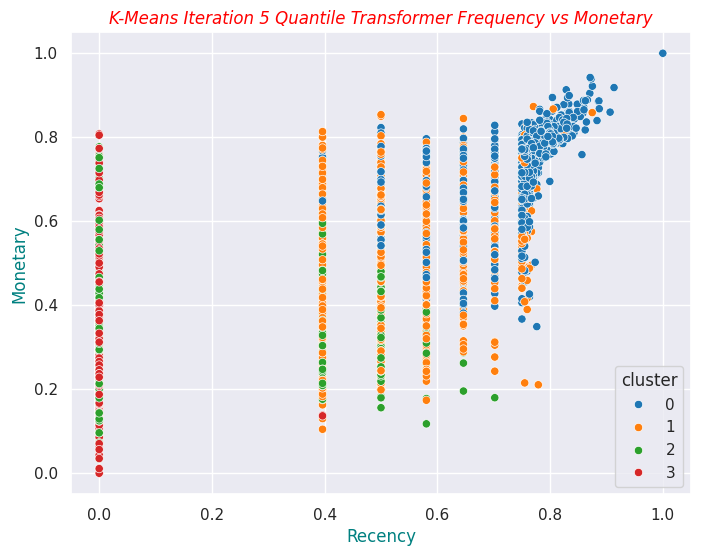

In [0]:
# scatter plot (No PCA)

# Frequency vs Monetary
import seaborn as sns

plt.figure(figsize= (8,6))
sns.scatterplot(
    data = base_iter5,
    x = 'Frequency_log',
    y = 'Monetary_log',
    hue = 'cluster',
    palette = 'tab10',
)

plt.title('K-Means Iteration 5 Quantile Transformer Frequency vs Monetary',
          color = 'red',
          style = 'italic')
plt.xlabel('Recency', color = 'teal')
plt.ylabel('Monetary', color = 'teal')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

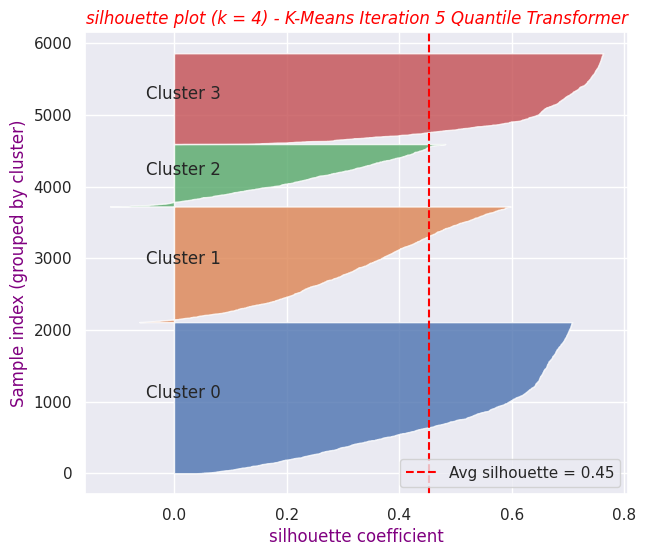

In [0]:
# silhouette Plot

sil_values_1 = silhouette_samples(X5_scaled, labels5)
sil_avg_1 = silhouette_score(X5_scaled, labels5)
plt.figure(figsize= (7,6))

y_lower = 0

vals0 = sil_values_1[labels5 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_1[labels5==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_1[labels5 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_1[labels5 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_1,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_1:.2f}"
)

plt.title('silhouette plot (k = 4) - K-Means Iteration 5 Quantile Transformer', color = 'red', style = 'italic')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.show